In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

In [7]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [8]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

In [10]:
serie = df['Passengers'].sort_index()

print(f"Nb de valeurs manquantes : {serie.isna().sum()}")
print(f"Fréquence inférée : {serie.index.inferred_freq}")
print("\nPremières valeurs :")
print(serie.head())

Nb de valeurs manquantes : 0
Fréquence inférée : MS

Premières valeurs :
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64


In [11]:
# ===== ÉTAPE 1 : Contrôle de la structure temporelle =====

print("=" * 60)
print("ÉTAPE 1 : CONTRÔLE DE LA STRUCTURE TEMPORELLE")
print("=" * 60)

print(f"\nType d'index : {type(serie.index)}")
print(f"Index est DatetimeIndex : {isinstance(serie.index, pd.DatetimeIndex)}")

print(f"\nPériode couverte :")
print(f"  - Début : {serie.index.min()}")
print(f"  - Fin : {serie.index.max()}")
print(f"  - Nombre d'observations : {serie.size}")
print(f"  - Durée totale : {serie.index.max() - serie.index.min()}")

print(f"\nValeurs manquantes : {serie.isna().sum()}")

ÉTAPE 1 : CONTRÔLE DE LA STRUCTURE TEMPORELLE

Type d'index : <class 'pandas.DatetimeIndex'>
Index est DatetimeIndex : True

Période couverte :
  - Début : 1949-01-01 00:00:00
  - Fin : 1960-12-01 00:00:00
  - Nombre d'observations : 144
  - Durée totale : 4352 days 00:00:00

Valeurs manquantes : 0


In [12]:
# ===== ÉTAPE 2 : Exploration rapide =====

print("\n" + "=" * 60)
print("ÉTAPE 2 : EXPLORATION RAPIDE")
print("=" * 60)

print("\nPremières observations :")
print(serie.head(12))

print("\nDernières observations :")
print(serie.tail(12))

print("\n--- Statistiques descriptives ---")
print(serie.describe())


ÉTAPE 2 : EXPLORATION RAPIDE

Premières observations :
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
Name: Passengers, dtype: int64

Dernières observations :
Month
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Passengers, dtype: int64

--- Statistiques descriptives ---
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


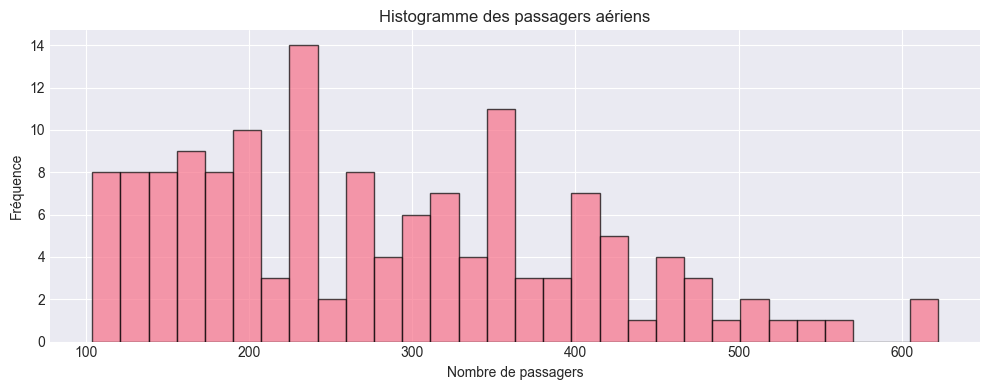

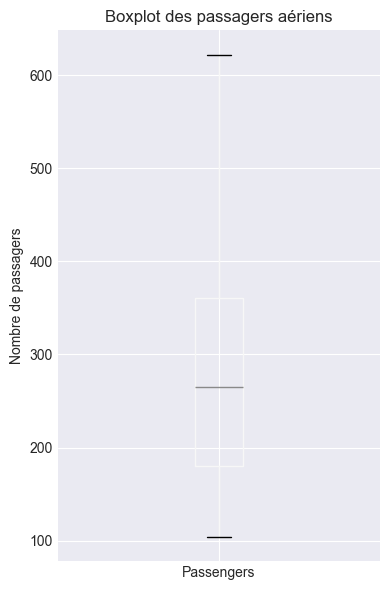


Médiane : 265.5
Moyenne : 280.2986111111111
Écart-type : 119.9663169429432


In [13]:
plt.figure(figsize=(10, 4))
serie.plot(kind="hist", bins=30, alpha=0.7, edgecolor='black')
plt.title("Histogramme des passagers aériens")
plt.xlabel("Nombre de passagers")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 6))
serie.to_frame("Passengers").boxplot(ax=ax)
plt.title("Boxplot des passagers aériens")
plt.ylabel("Nombre de passagers")
plt.tight_layout()
plt.show()

print(f"\nMédiane : {serie.median()}")
print(f"Moyenne : {serie.mean()}")
print(f"Écart-type : {serie.std()}")


ÉTAPE 3 : VISUALISATIONS ESSENTIELLES


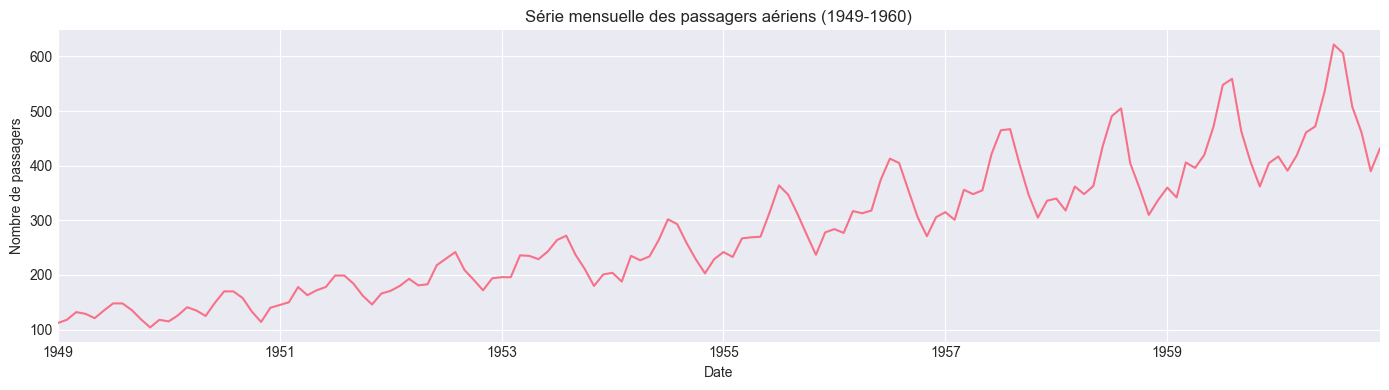

In [14]:
# ===== ÉTAPE 3 : Visualisations essentielles =====

print("\n" + "=" * 60)
print("ÉTAPE 3 : VISUALISATIONS ESSENTIELLES")
print("=" * 60)

# Vue globale
plt.figure(figsize=(14, 4))
serie.plot(title="Série mensuelle des passagers aériens (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.tight_layout()
plt.show()

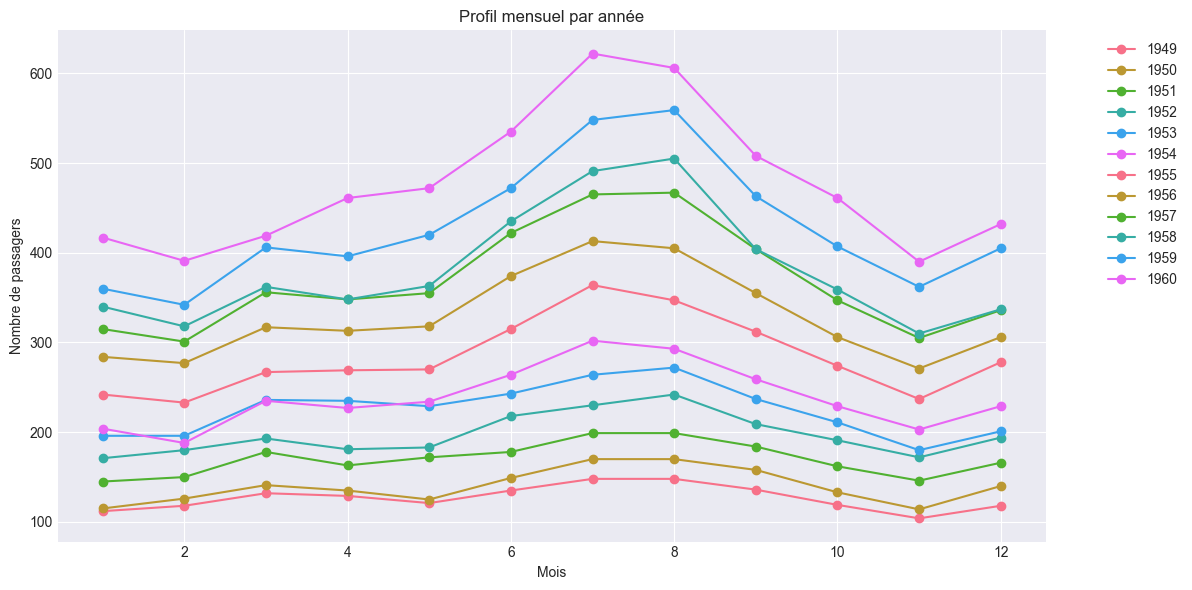

In [15]:
years = serie.groupby(serie.index.year)
plt.figure(figsize=(12, 6))
for year, group in years:
    plt.plot(group.index.month, group.values, marker='o', label=str(year))
plt.xlabel("Mois")
plt.ylabel("Nombre de passagers")
plt.title("Profil mensuel par année")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

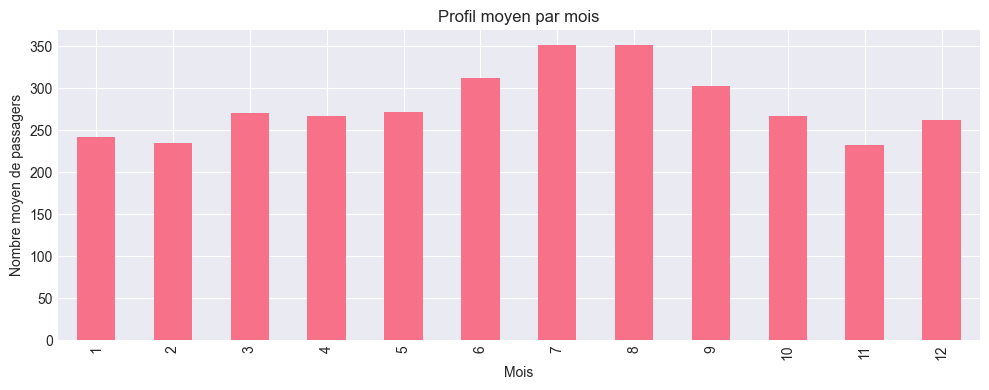

In [16]:
# Cycle mensuel
serie.groupby(serie.index.month).mean().plot(kind="bar", figsize=(10, 4))
plt.title("Profil moyen par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre moyen de passagers")
plt.tight_layout()
plt.show()